<a href="https://colab.research.google.com/github/johnsparz/Flexisaf_Task4/blob/master/Digit_Recognition_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Handwritten Digit Recognition using PyTorch**

### **STEP 1 — Project Setup**

In [48]:
import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from torch import nn
from torch.utils.data import DataLoader

In [49]:
print(torch.__version__)

2.11.0+cu128


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [51]:
torch.manual_seed(42)

### **STEP 2 — Download the MNIST Dataset**

In [52]:
transform = transforms.ToTensor()

In [53]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [54]:
print(len(train_dataset))
print(len(test_dataset))

60000
10000


In [55]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
5


### **STEP 3 – Visualize the MNIST Dataset**

In [56]:
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)

Image Shape: torch.Size([1, 28, 28])
Label: 5


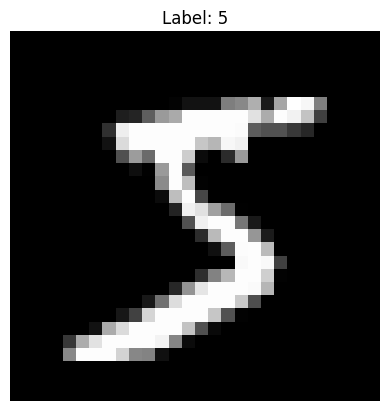

In [57]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

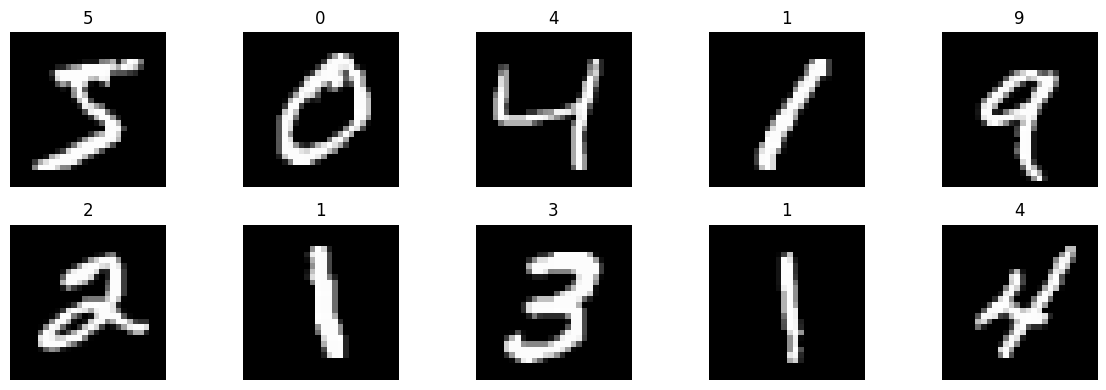

In [58]:
plt.figure(figsize=(12, 4))

for i in range(10):
    image, label = train_dataset[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

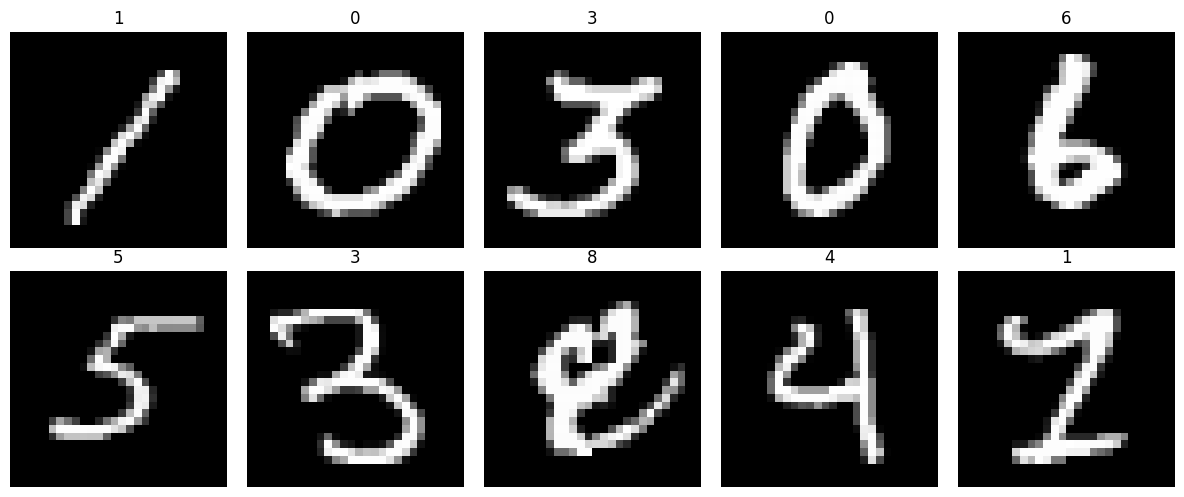

In [59]:
import random

plt.figure(figsize=(12, 5))

for i in range(10):
    index = random.randint(0, len(train_dataset) - 1)

    image, label = train_dataset[index]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"{label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [60]:
print(type(image))

<class 'torch.Tensor'>


In [61]:
print(image.min())
print(image.max())

tensor(0.)
tensor(1.)


In [62]:
print(image.squeeze())

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [63]:
print(train_dataset.classes)

['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [64]:
print("Number of Classes:", len(train_dataset.classes))

Number of Classes: 10


### **STEP 4 – Create DataLoaders**

In [65]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [66]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


### **STEP 5 – Build the Neural Network**
**We'll use a simple Feedforward Neural Network (FNN).**

In [67]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            # nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [68]:
model = DigitClassifier().to(device)

print(model)

DigitClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


### **STEP 6 – Loss Function and Optimizer**

In [69]:
criterion = nn.CrossEntropyLoss()

In [70]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### **STEP 7 – Train the Model**

In [71]:
epochs = 5

In [72]:
train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] Loss: 0.3096 Accuracy: 91.26%
Epoch [2/5] Loss: 0.1231 Accuracy: 96.30%
Epoch [3/5] Loss: 0.0855 Accuracy: 97.36%
Epoch [4/5] Loss: 0.0642 Accuracy: 97.95%
Epoch [5/5] Loss: 0.0490 Accuracy: 98.46%


### **STEP 8 – Plot Training Performance**

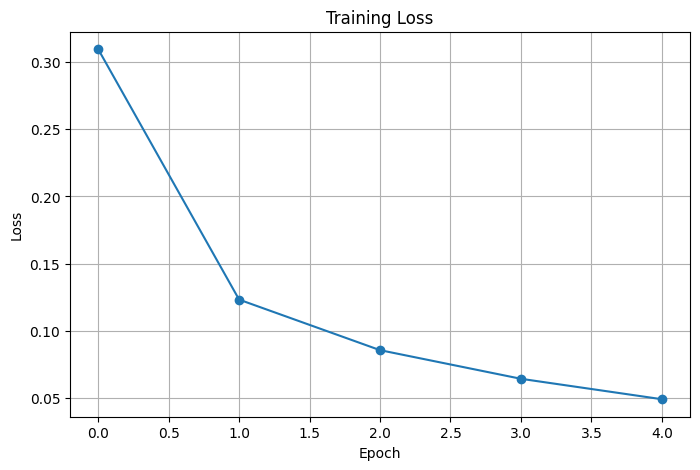

In [73]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### **STEP 9 – Evaluate the Model**

In [74]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 97.25%


### **STEP 10 – Display Predictions**

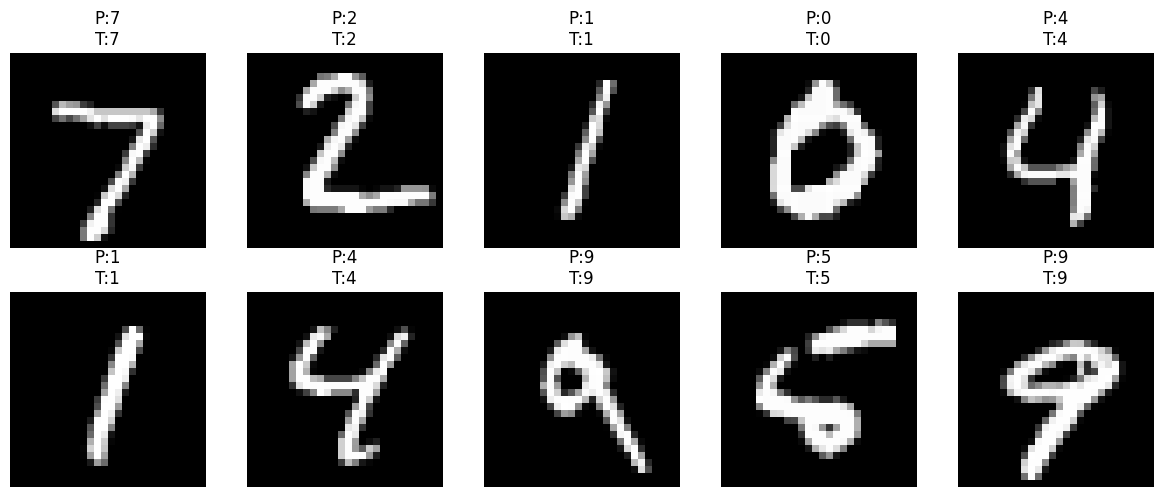

In [75]:
images, labels = next(iter(test_loader))

images = images.to(device)

outputs = model(images)

_, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"P:{predicted[i]}\nT:{labels[i]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

### **STEP 11 – Confusion Matrix**

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [77]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

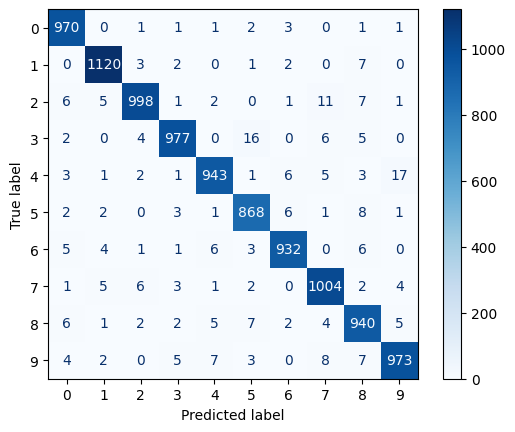

In [78]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()

### **STEP 12 – Save the Model**

In [79]:
torch.save(model.state_dict(), "mnist_model.pth")

### **STEP 13 – Load the Model**

In [80]:
model = DigitClassifier().to(device)

model.load_state_dict(torch.load("mnist_model.pth", map_location=device))

model.eval()

DigitClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

### **STEP 14 – Predict a Single Image**

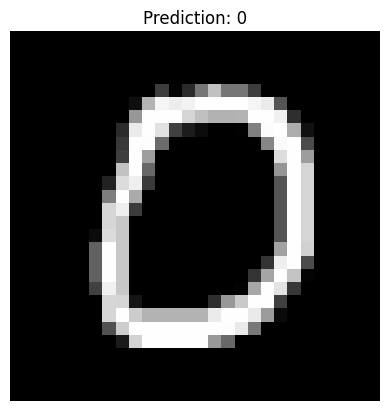

In [81]:
image, label = test_dataset[10]

model.eval()

with torch.no_grad():

    prediction = model(image.unsqueeze(0).to(device))

    predicted = prediction.argmax(dim=1).item()

plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Prediction: {predicted}")

plt.axis("off")

plt.show()